In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dowhy import CausalModel
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from econml.inference import BootstrapInference


In [61]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))


df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)

download_order = [
    '<100','100-500','500-1k','1k-5k','5k-10k','10k-50k',
    '50k-100k','100k-500k','500k-1M','1M-5M','>5M'
]
ord_map = {c: i for i, c in enumerate(download_order)}
df["app_popularity_encoded"] = df["app_popularity"].map(ord_map)

df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

print("\napp_popularity_encoded counts:")
print(df["app_popularity_encoded"].value_counts().sort_index())


Original rows: 6140
After removing obfuscated: 5612

app_popularity_encoded counts:
app_popularity_encoded
0     626
1     604
2     317
3     323
4     415
5     449
6     413
7     704
8     602
9     641
10    518
Name: count, dtype: int64


In [62]:
majority = df[df["is_third_party"] == 1]
minority = df[df["is_third_party"] == 0]
n_min = len(minority)
down_sample = majority.sample(n=n_min, replace=False, random_state=42)

df = pd.concat([down_sample, minority], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["is_third_party"].value_counts())
print(df["app_popularity_encoded"].value_counts().sort_index())

is_third_party
0    511
1    511
Name: count, dtype: int64
app_popularity_encoded
0     138
1     101
2      67
3      71
4      68
5      73
6     102
7     120
8     111
9      82
10     89
Name: count, dtype: int64


In [63]:
# We got this graph from the causal_analysis_binary_treatment.ipynb notebook 
causal_graph = """
digraph {
    is_third_party -> verdict;
    app_popularity -> is_third_party;
    app_popularity -> verdict;
    app_popularity -> apk_size_scaled;
    apk_size_scaled -> is_third_party;
}
"""

model = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph.replace("\n", " "),
    common_causes=["app_popularity_encoded"],
    effect_modifiers=["app_popularity_encoded"]   
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                   
─────────────────(E[verdict|app_popularity])
d[is_third_party]                           
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,app_popularity,U) = P(verdict|is_third_party,app_popularity)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                   
─────────────────(E[verdict|app_popularity])
d[is_third_party]                           
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,app_popularity,U) = P(verdict|is_third_party,app_popularity)



In [64]:
from dowhy import CausalModel

cf_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.CausalForestDML",
    target_units="ate",          
    confidence_intervals=False,
    effect_modifiers=["app_popularity_encoded"],
    method_params={
        "init_params": {
            "model_y": RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=10,
                random_state=42                
            ),
            "model_t": RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=10,
                random_state=42
            ),
            "n_estimators": 500,
            "min_samples_leaf": 5,
            "discrete_treatment": True,
            "random_state": 42
        },
        "fit_params": {}
    }
)

print(cf_estimate)           
print("Mean ATE:", cf_estimate.value)


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                   
─────────────────(E[verdict|app_popularity])
d[is_third_party]                           
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,app_popularity,U) = P(verdict|is_third_party,app_popularity)

## Realized estimand
b: verdict~is_third_party+app_popularity | app_popularity_encoded
Target units: ate

## Estimate
Mean value: -0.24633805401915448
Effect estimates: [[-0.22840339]
 [-0.17046799]
 [-0.31293404]
 ...
 [-0.38868125]
 [-0.22840339]
 [-0.37966917]]

Mean ATE: -0.24633805401915448


In [65]:
# Here we are calculating CATE by app popularity bucket

cf_raw = cf_estimate._estimator_object
tau_hat = cf_raw.effect(df[["app_popularity_encoded"]].values)
df["tau_popularity"] = tau_hat
group_col = "app_popularity" 

cate_by_popularity = (
    df.groupby(group_col)["tau_popularity"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

download_order = [
    '<100','100-500','500-1k','1k-5k','5k-10k','10k-50k',
    '50k-100k','100k-500k','500k-1M','1M-5M','>5M'
]
if group_col == "app_popularity":
    cate_by_popularity["order"] = cate_by_popularity["app_popularity"].map({c:i for i,c in enumerate(download_order)})
    cate_by_popularity = cate_by_popularity.sort_values("order")

print("\nCATE of is_third_party vs dev, by app popularity bucket:")
print(cate_by_popularity[["app_popularity", "mean", "std", "count"]] if group_col == "app_popularity" else cate_by_popularity)



CATE of is_third_party vs dev, by app popularity bucket:
   app_popularity      mean  std  count
9            <100 -0.065106  0.0    138
0         100-500 -0.228403  0.0    101
5          500-1k -0.388681  0.0     67
4           1k-5k -0.617382  0.0     71
8          5k-10k  0.116290  0.0     68
2         10k-50k -0.379669  0.0     73
7        50k-100k -0.156210  0.0    102
1       100k-500k -0.185939  0.0    120
6         500k-1M -0.449952  0.0    111
3           1M-5M -0.170468  0.0     82
10            >5M -0.312934  0.0     89


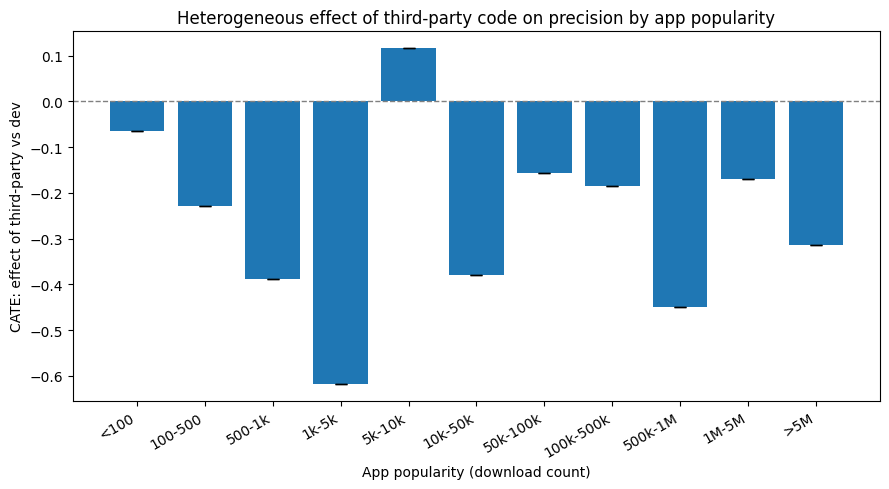

In [66]:
labels = cate_by_popularity[group_col].tolist()
means = cate_by_popularity["mean"].values
stds  = cate_by_popularity["std"].values

x = np.arange(len(labels))

plt.figure(figsize=(9, 5))
plt.bar(x, means, yerr=stds, capsize=4)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("CATE: effect of third-party vs dev")
plt.xlabel("App popularity (download count)")
plt.title("Heterogeneous effect of third-party code on precision by app popularity")
plt.tight_layout()
plt.show()

In [67]:
res_random = model.refute_estimate(
    identified_estimand,
    cf_estimate,
    method_name="random_common_cause"
)
print("\n[Random common cause]")
print(res_random)

res_placebo = model.refute_estimate(
    identified_estimand,
    cf_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=20  
)
print("\n[Placebo treatment]")
print(res_placebo)

res_subset = model.refute_estimate(
    identified_estimand,
    cf_estimate,
    method_name="data_subset_refuter",
    num_simulations=20
)
print("\n[Data subset]")
print(res_subset)



[Random common cause]
Refute: Add a random common cause
Estimated effect:-0.24633805401915448
New effect:-0.24093408306132041
p value:0.7


[Placebo treatment]
Refute: Use a Placebo Treatment
Estimated effect:-0.24633805401915448
New effect:-0.0052171620574393675
p value:0.42419359571358495


[Data subset]
Refute: Use a subset of data
Estimated effect:-0.24633805401915448
New effect:-0.23725811667342417
p value:0.28214419008313174

